# Sampling comparison: real pulsar catalog vs m12i mock measurements

Donlon+ (2025) Fig. 1-style figure, but overlaying **both** datasets:

- **top** — histogram + KDE of heliocentric distance $r_\odot$;
- **bottom** — the implied pulsar number density $n(r_\odot) = N\,p(r_\odot)/(4\pi r_\odot^2)$, with the 1 pulsar/kpc$^3$ "sufficient sampling" reference line.

Kernel: `sci-py312`.

In [27]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import scienceplots  # noqa: F401 — registers the styles

plt.style.use(["science", "no-latex"])
plt.rcParams["figure.dpi"] = 150

PAPER_PALETTE = ["#638ccc", "#c57c3c", "#ab62c0", "#72a555", "#ca5670"]
C_CAT, C_SIM = PAPER_PALETTE[:2]  # catalog blue, m12i orange
C_REF = "0.45"                    # grey for the uniform-in-ball reference curves

## Real catalog (Donlon 2025)

Same load as `dataset_visualization/dataset.ipynb`: skip the units row, drop the
`J0737-3039B` duplicate (same binary as A) → 52 pulsars. The heliocentric distance
is the `DIST` column (kpc).

In [28]:
data_path = "/Users/pablom.perez/Desktop/Linas-group/data/pulsars/data.csv"
df = pd.read_csv(data_path, skiprows=[1])
df = df[df["NAME"] != "J0737-3039B"].reset_index(drop=True)
r_cat = df["DIST"].to_numpy()
print(f"{len(r_cat)} pulsars, r_sun in [{r_cat.min():.2f}, {r_cat.max():.2f}] kpc")

52 pulsars, r_sun in [0.16, 10.00] kpc


## m12i mock measurement positions

How the mock "pulsars" were placed (`clean_experiments/fire_sims/fire_truth.py`):

1. tracers = star particles with **age > 1 Gyr** (MSP-like) in the m12i snapshot;
2. keep those inside the **4 kpc training ball** around the Sun at $(-8.1, 0, 0)$ kpc
   (principal-axis frame);
3. draw a **30,000-particle pool uniformly** among them (seed 0).

Because the pool is a uniform draw *from the particles themselves*, its positions follow
the simulation's own stellar density — no analytic density model or rejection sampling.
Every training set of size $n$ is then a uniform subsample of this pool
(`run_noise_vmap.py`), so the pool **is** the sampling distribution of the mock
measurement positions.

In [29]:
truth_path = "../../experiments/fire_los_recovery/cache/truth_old1gyr.npz"
OBSERVER = np.array([-8.1, 0.0, 0.0])  # kpc, matches fire_truth.py
R_BALL = 4.0                           # kpc, training-ball radius (fire_truth.py)
pool = np.load(truth_path)
x_sim = pool["x_pool"]                 # (30000, 3) principal-axis frame, kpc
r_sim = np.linalg.norm(x_sim - OBSERVER, axis=1)
print(f"{len(r_sim)} pool tracers, r_sun in [{r_sim.min():.2f}, {r_sim.max():.2f}] kpc")

30000 pool tracers, r_sun in [0.06, 4.00] kpc


## KDEs and number density

- $p(r_\odot)$ from `gaussian_kde` (Scott bandwidth). Histograms are density-normalized
  so 52 pulsars and 30k tracers are comparable.
- Number density assumes isotropy: $n(r) = N\,p(r) / (4\pi r^2)$, with $N=52$ real
  pulsars vs $n=50$ mocks (our canonical low-$n$ training size).
- **Uniform-in-volume reference** (grey dashed): a sample spread uniformly inside the
  4 kpc ball has $N(<r) = N\,(r/R)^3$, hence $p(r) = 3r^2/R^3$ (the $r^3$ lives in the
  *cumulative* count; the PDF is its derivative $\propto r^2$) and a flat
  $n = N/V_{\rm ball} = 50/268\ \mathrm{kpc^{-3}} = 0.19$. No fit is needed: the ball
  radius fixes the normalisation. The mock pool is *not* uniform in volume by
  construction — it is a uniform draw of *particles*, so it traces the old-star number
  density inside the ball (denser in the plane / inner disk than at $|z| \sim 3$ kpc) —
  so this line is the null hypothesis the mock should deviate from, mildly.

Two caveats baked into the plotting choices below:

- 3 catalog pulsars sit at 4.2–10 kpc (J1721-2457, J2229+2643, B1913+16), so ~12% of
  the catalog KDE mass lies beyond the plotted window — annotated on the top panel.
- the density grid starts at $r = 0.15$ kpc: dividing the KDE by $4\pi r^2$ diverges
  spuriously as $r \to 0$ (Donlon's Fig. 1 curve also starts off-axis).

In [30]:
kde_cat, kde_sim = gaussian_kde(r_cat), gaussian_kde(r_sim)

rg = np.linspace(0.0, 4.5, 400)            # PDF panel grid
p_cat, p_sim = kde_cat(rg), kde_sim(rg)

N_cat, N_sim = len(r_cat), 50
rn = np.linspace(0.15, 4.5, 400)           # density panel grid (avoid r -> 0)
n_cat = N_cat * kde_cat(rn) / (4 * np.pi * rn**2)
n_sim = N_sim * kde_sim(rn) / (4 * np.pi * rn**2)

# uniform-in-volume reference inside the training ball (parameter-free)
V_BALL = 4 / 3 * np.pi * R_BALL**3
p_uni = np.where(rg <= R_BALL, 3 * rg**2 / R_BALL**3, np.nan)   # dN/dr ∝ r^2
n_uni = N_sim / V_BALL                                          # flat, 0.19 kpc^-3

# how far is the mock from uniform-in-volume? effective log-slope of p_sim(r)
m = (rg > 0.3) & (rg < 3.5)
slope = np.polyfit(np.log(rg[m]), np.log(p_sim[m]), 1)[0]
print(f"m12i pool: d ln p / d ln r = {slope:.2f} over 0.3-3.5 kpc (uniform volume: 2)")
print(f"n_sim(0.5 kpc) = {N_sim * kde_sim(0.5)[0] / (4 * np.pi * 0.5**2):.2f}, "
      f"n_sim(3.5 kpc) = {N_sim * kde_sim(3.5)[0] / (4 * np.pi * 3.5**2):.2f}, "
      f"uniform = {n_uni:.2f} kpc^-3")

m12i pool: d ln p / d ln r = 1.74 over 0.3-3.5 kpc (uniform volume: 2)
n_sim(0.5 kpc) = 0.29, n_sim(3.5 kpc) = 0.18, uniform = 0.19 kpc^-3


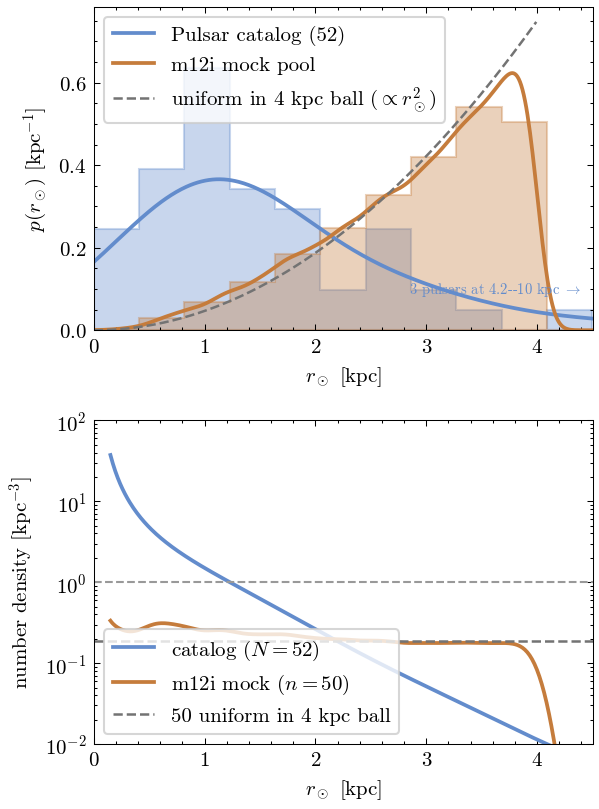

In [31]:
bins = np.linspace(0.0, 4.5, 12)
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(4.2, 5.6))

ax0.hist(r_cat, bins=bins, density=True, histtype="stepfilled",
         color=C_CAT, alpha=0.35, edgecolor=C_CAT, lw=1.2)
ax0.hist(r_sim, bins=bins, density=True, histtype="stepfilled",
         color=C_SIM, alpha=0.35, edgecolor=C_SIM, lw=1.2)
ax0.plot(rg, p_cat, color=C_CAT, lw=1.8, label="Pulsar catalog (52)")
ax0.plot(rg, p_sim, color=C_SIM, lw=1.8, label="m12i mock pool")
ax0.plot(rg, p_uni, color=C_REF, ls="--", lw=1.2,
         label=r"uniform in 4 kpc ball ($\propto r_\odot^2$)")
ax0.annotate(r"3 pulsars at 4.2--10 kpc $\rightarrow$", xy=(4.4, 0.09),
             ha="right", fontsize=7, color=C_CAT)
ax0.set_xlim(0, 4.5)
ax0.set_xlabel(r"$r_\odot$ [kpc]")
ax0.set_ylabel(r"$p(r_\odot)$ [kpc$^{-1}$]")
ax0.legend(frameon=True)

ax1.plot(rn, n_cat, color=C_CAT, lw=1.8, label=r"catalog ($N=52$)")
ax1.plot(rn, n_sim, color=C_SIM, lw=1.8, label=r"m12i mock ($n=50$)")
ax1.axhline(n_uni, color=C_REF, ls="--", lw=1.2, label="50 uniform in 4 kpc ball")
ax1.axhline(1.0, color="0.6", ls="--", lw=1)
ax1.set_yscale("log")
ax1.set_ylim(1e-2, 1e2)
ax1.set_xlim(0, 4.5)
ax1.set_xlabel(r"$r_\odot$ [kpc]")
ax1.set_ylabel(r"number density [kpc$^{-3}$]")
ax1.legend(frameon=True, loc="lower left")

fig.tight_layout()
# fig.savefig("../../../accelerations-paper/figures/sampling_comparison.pdf")

## The $r^3$ check: cumulative fraction within $r_\odot$

This is where a $k\,r^3$ line belongs: for uniform-in-volume sampling
$N(<r)/N = (r/R)^3$ with $k = 1/R^3$ fixed by the ball, no fit. Log-log axes turn the
power law into a straight line of slope 3, so a departure shows up as a different
*slope* rather than a different normalisation. The mock runs parallel to and slightly
above the line — a bit more concentrated toward the Sun than uniform, because the
old-star density drops toward the top/bottom of the ball — while the catalog is ~10×
above it at 1 kpc (nearby pulsars are heavily over-represented).

m12i pool: d ln N(<r) / d ln r = 2.74 (uniform volume: 3)


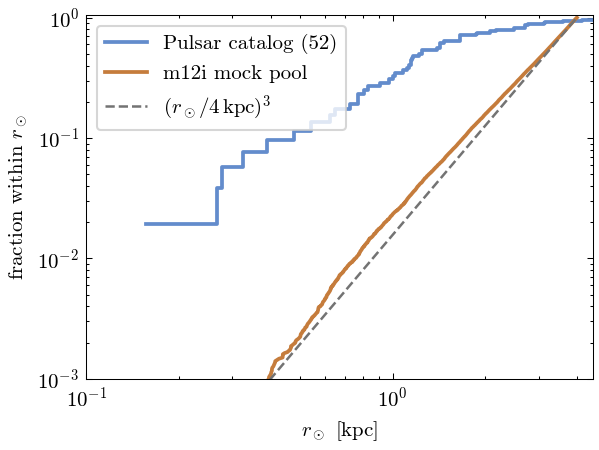

In [32]:
r_s, F_s = np.sort(r_sim), np.arange(1, len(r_sim) + 1) / len(r_sim)
r_c, F_c = np.sort(r_cat), np.arange(1, len(r_cat) + 1) / len(r_cat)
rr = np.linspace(0.05, R_BALL, 200)

m = (r_s > 0.5) & (r_s < 3.0)
print(f"m12i pool: d ln N(<r) / d ln r = "
      f"{np.polyfit(np.log(r_s[m]), np.log(F_s[m]), 1)[0]:.2f} (uniform volume: 3)")

fig, ax = plt.subplots(figsize=(4.2, 3.2))
ax.step(r_c, F_c, where="post", color=C_CAT, lw=1.8, label="Pulsar catalog (52)")
ax.plot(r_s, F_s, color=C_SIM, lw=1.8, label="m12i mock pool")
ax.plot(rr, (rr / R_BALL) ** 3, color=C_REF, ls="--", lw=1.2,
        label=r"$(r_\odot / 4\,\mathrm{kpc})^3$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(0.1, 4.5)
ax.set_ylim(1e-3, 1.05)
ax.set_xlabel(r"$r_\odot$ [kpc]")
ax.set_ylabel(r"fraction within $r_\odot$")
ax.legend(frameon=True, loc="upper left")
fig.tight_layout()

## Same comparison in Galactocentric azimuth $\phi$ and height $z$

The catalog only has $(\ell, b, d)$, so convert to the mock's Galactocentric frame with
the Sun at $(-8.1, 0, 0)$ kpc: $x = -8.1 + d\cos b\cos\ell$, $y = d\cos b\sin\ell$,
$z = d\sin b$ (right-handed, $+y$ toward $\ell = 90^\circ$; the Sun's 20 pc offset from the
plane is ignored, as in the mock). Azimuth is measured from the Sun's direction,
$\phi = \operatorname{atan2}(y, -x)$, so the 4 kpc ball spans
$|\phi| \le \arcsin(4/8.1) = 29.6^\circ$. For the m12i frame the sign of $\phi$ is a
convention (the principal axes fix $|z|$, not the sense of rotation), so only the
*spread* is comparable.

The uniform-in-ball reference is now a Monte-Carlo draw (uniform directions,
$r \propto u^{1/3}$) pushed through the same functions; for $z$ it is also analytic,
$p(z) = 3(R^2 - z^2)/(4R^3)$. Two catalog pulsars fall outside the $\phi$ window:
J1721-2457 (10 kpc, $\ell = 0.4^\circ$, i.e. beyond the Galactic centre at $\phi = 178^\circ$)
and — just outside the ball — B1913+16 at $30.5^\circ$; all 52 fit in the $z$ window.

phi std [deg]: catalog (r<4 kpc) 7.3, m12i 14.3, uniform 12.9
median |z| [kpc]: catalog 0.42, m12i 0.66, uniform 1.39


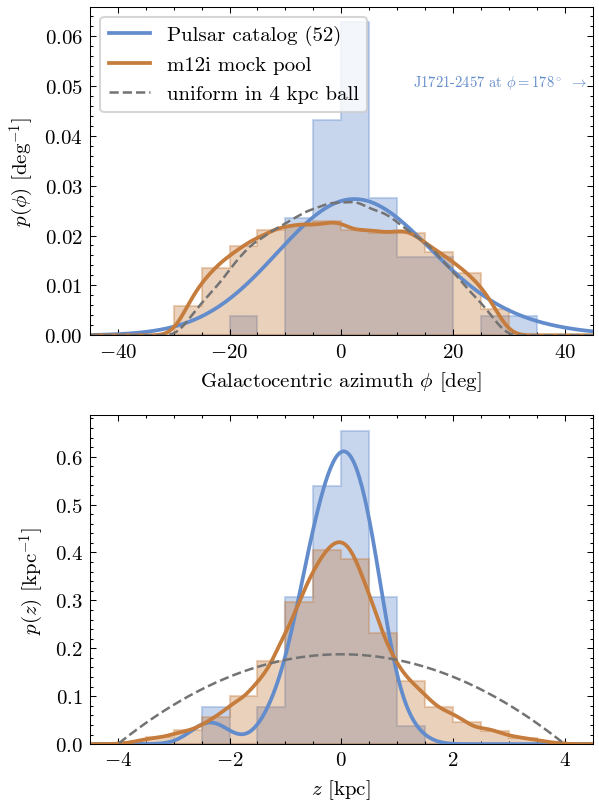

In [33]:
def galactocentric(l_deg, b_deg, d, observer=OBSERVER):
    """(l, b, d) -> Galactocentric Cartesian [kpc], Sun at `observer`, z toward the NGP."""
    l, b = np.radians(l_deg), np.radians(b_deg)
    return np.stack([observer[0] + d * np.cos(b) * np.cos(l),
                     d * np.cos(b) * np.sin(l),
                     d * np.sin(b)], axis=1)


def azimuth_deg(x):
    """Galactocentric azimuth: 0 at the Sun, increasing toward l = 90 deg (+y)."""
    return np.degrees(np.arctan2(x[:, 1], -x[:, 0]))


x_cat = galactocentric(df["GL"].to_numpy(), df["GB"].to_numpy(), r_cat)
phi_cat, phi_sim = azimuth_deg(x_cat), azimuth_deg(x_sim)
z_cat, z_sim = x_cat[:, 2], x_sim[:, 2]

# uniform-in-ball reference by Monte Carlo (same functions as the data)
rng = np.random.default_rng(1)
v = rng.normal(size=(100_000, 3))
v /= np.linalg.norm(v, axis=1, keepdims=True)
x_uni = OBSERVER + (R_BALL * rng.uniform(size=len(v)) ** (1 / 3))[:, None] * v
phi_uni, z_uni = azimuth_deg(x_uni), x_uni[:, 2]

print(f"phi std [deg]: catalog (r<4 kpc) {phi_cat[r_cat < R_BALL].std():.1f}, "
      f"m12i {phi_sim.std():.1f}, uniform {phi_uni.std():.1f}")
print(f"median |z| [kpc]: catalog {np.median(np.abs(z_cat)):.2f}, "
      f"m12i {np.median(np.abs(z_sim)):.2f}, uniform {np.median(np.abs(z_uni)):.2f}")

phig, zg = np.linspace(-45, 45, 400), np.linspace(-4.5, 4.5, 400)
p_phi_cat, p_phi_sim, p_phi_uni = (gaussian_kde(s)(phig) for s in (phi_cat, phi_sim, phi_uni))
p_z_cat, p_z_sim = (gaussian_kde(s)(zg) for s in (z_cat, z_sim))
p_z_uni = np.where(np.abs(zg) <= R_BALL, 3 * (R_BALL**2 - zg**2) / (4 * R_BALL**3), np.nan)

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(4.2, 5.6))

bphi = np.linspace(-45, 45, 19)
ax0.hist(phi_cat, bins=bphi, density=True, histtype="stepfilled",
         color=C_CAT, alpha=0.35, edgecolor=C_CAT, lw=1.2)
ax0.hist(phi_sim, bins=bphi, density=True, histtype="stepfilled",
         color=C_SIM, alpha=0.35, edgecolor=C_SIM, lw=1.2)
ax0.plot(phig, p_phi_cat, color=C_CAT, lw=1.8, label="Pulsar catalog (52)")
ax0.plot(phig, p_phi_sim, color=C_SIM, lw=1.8, label="m12i mock pool")
ax0.plot(phig, p_phi_uni, color=C_REF, ls="--", lw=1.2, label="uniform in 4 kpc ball")
ax0.annotate(r"J1721-2457 at $\phi = 178^\circ$ $\rightarrow$", xy=(44, 0.05),
             ha="right", fontsize=7, color=C_CAT)
ax0.set_xlim(-45, 45)
ax0.set_xlabel(r"Galactocentric azimuth $\phi$ [deg]")
ax0.set_ylabel(r"$p(\phi)$ [deg$^{-1}$]")
ax0.legend(frameon=True)

bz = np.linspace(-4.5, 4.5, 19)
ax1.hist(z_cat, bins=bz, density=True, histtype="stepfilled",
         color=C_CAT, alpha=0.35, edgecolor=C_CAT, lw=1.2)
ax1.hist(z_sim, bins=bz, density=True, histtype="stepfilled",
         color=C_SIM, alpha=0.35, edgecolor=C_SIM, lw=1.2)
ax1.plot(zg, p_z_cat, color=C_CAT, lw=1.8)
ax1.plot(zg, p_z_sim, color=C_SIM, lw=1.8)
ax1.plot(zg, p_z_uni, color=C_REF, ls="--", lw=1.2)
ax1.set_xlim(-4.5, 4.5)
ax1.set_xlabel(r"$z$ [kpc]")
ax1.set_ylabel(r"$p(z)$ [kpc$^{-1}$]")

fig.tight_layout()
# fig.savefig("../../../accelerations-paper/figures/sampling_comparison_phi_z.pdf")

## Fully heliocentric version: $(r_\odot, \ell, b)$

The catalog's native coordinates are heliocentric spherical: distance $r_\odot$
(`DIST`), Galactic longitude $\ell$ (`GL`, 0 toward the Galactic centre, increasing toward
$\ell = 90^\circ$) and latitude $b$ (`GB`, $+90^\circ$ at the north Galactic pole). This
figure uses that triple throughout, unlike the $(\phi, z)$ panels above, which mix a
heliocentric radius with Galactocentric angles.

- **mock**: $(\ell, b)$ of each pool particle as seen from the Sun at $(-8.1, 0, 0)$ kpc,
  i.e. from $\mathbf{d} = \mathbf{x} - \mathbf{x}_\odot$ with $\ell = \operatorname{atan2}(d_y, d_x)$
  and $b = \arcsin(d_z/|\mathbf{d}|)$. As for $\phi$, the sign of $\ell$ is a convention in
  the m12i frame; the axisymmetric disk makes the distribution symmetric anyway.
- $\ell$ is wrapped to $(-180^\circ, 180^\circ]$ so the Galactic centre sits mid-axis and
  the anticentre at the edges. The $\ell$ KDE is made periodic by tiling the sample by
  $\pm 360^\circ$ (bandwidth from the untiled sample, otherwise Scott's rule inflates it).
- **uniform-in-ball reference**: isotropic around the Sun, so $p(\ell) = 1/360^\circ$
  and $p(b) = \tfrac{1}{2}\cos b$ per radian — the ball radius drops out entirely.

Both samples prefer the inner Galaxy ($|\ell| < 90^\circ$: 71% catalog, 79% mock, vs 50%
isotropic) and the plane (median $|b|$: $20^\circ$ catalog, $14^\circ$ mock, $30^\circ$
isotropic). The catalog's $b$ distribution is broader than the mock's *despite* its
smaller $|z|$, because its pulsars are much closer: a fixed $|z| \sim 0.4$ kpc subtends a
larger angle at $r_\odot \sim 1$ kpc than the mock's $|z| \sim 0.7$ kpc at $3.5$ kpc.

fraction with |l| < 90 deg: catalog 0.71, m12i 0.79, uniform ball 0.50
median |b| [deg]: catalog 19.9, m12i 14.1, uniform ball 30.0


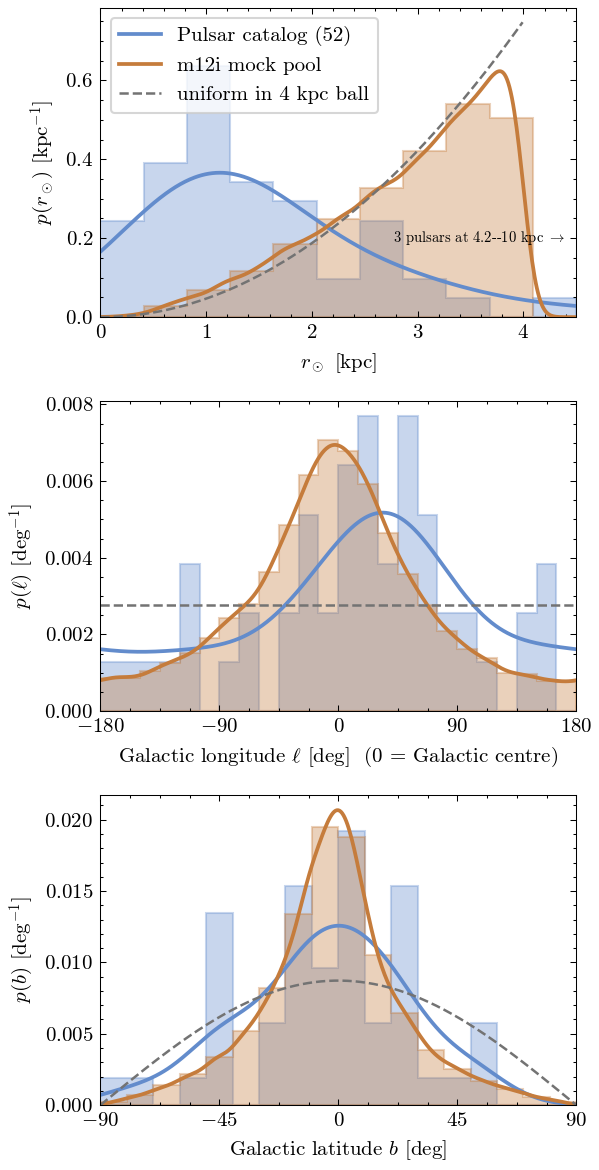

In [34]:
def heliocentric_lb(x, observer=OBSERVER):
    """Galactocentric Cartesian -> Galactic (l, b) in degrees as seen from `observer`.
    l = 0 toward the Galactic centre (+x), l = 90 toward +y, b = 90 toward +z.
    l is wrapped to (-180, 180] so the centre sits mid-axis."""
    d = x - observer
    l = np.degrees(np.arctan2(d[:, 1], d[:, 0]))
    b = np.degrees(np.arcsin(d[:, 2] / np.linalg.norm(d, axis=1)))
    return l, b


def wrap180(l_deg):
    return (l_deg + 180.0) % 360.0 - 180.0


def periodic_kde(sample, grid, period=360.0):
    """KDE on a periodic coordinate: tile the sample by +-period, evaluate, x3.
    The bandwidth is Scott's rule on the *untiled* sample (tiling would inflate it)."""
    h = gaussian_kde(sample).factor * sample.std(ddof=1)     # bandwidth [deg]
    tiled = np.concatenate([sample - period, sample, sample + period])
    kde = gaussian_kde(tiled, bw_method=h / tiled.std(ddof=1))
    return 3.0 * kde(grid)


l_cat, b_cat = wrap180(df["GL"].to_numpy()), df["GB"].to_numpy()
l_sim, b_sim = heliocentric_lb(x_sim)

lg, bg = np.linspace(-180, 180, 721), np.linspace(-90, 90, 361)
p_l_cat, p_l_sim = periodic_kde(l_cat, lg), periodic_kde(l_sim, lg)
p_b_cat, p_b_sim = gaussian_kde(b_cat)(bg), gaussian_kde(b_sim)(bg)
p_l_uni = np.full_like(lg, 1 / 360)                          # isotropic: flat in l
p_b_uni = np.radians(1) * np.cos(np.radians(bg)) / 2         # isotropic: cos(b) / 2 per rad

print(f"fraction with |l| < 90 deg: catalog {np.mean(np.abs(l_cat) < 90):.2f}, "
      f"m12i {np.mean(np.abs(l_sim) < 90):.2f}, uniform ball 0.50")
print(f"median |b| [deg]: catalog {np.median(np.abs(b_cat)):.1f}, "
      f"m12i {np.median(np.abs(b_sim)):.1f}, uniform ball 30.0")

fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(4.2, 8.0))

# r_sun: same as the top panel of the main figure
ax0.hist(r_cat, bins=bins, density=True, histtype="stepfilled",
         color=C_CAT, alpha=0.35, edgecolor=C_CAT, lw=1.2)
ax0.hist(r_sim, bins=bins, density=True, histtype="stepfilled",
         color=C_SIM, alpha=0.35, edgecolor=C_SIM, lw=1.2)
ax0.plot(rg, p_cat, color=C_CAT, lw=1.8, label="Pulsar catalog (52)")
ax0.plot(rg, p_sim, color=C_SIM, lw=1.8, label="m12i mock pool")
ax0.plot(rg, p_uni, color=C_REF, ls="--", lw=1.2, label="uniform in 4 kpc ball")
ax0.annotate(r"3 pulsars at 4.2--10 kpc $\rightarrow$", xy=(4.4, 0.19),
             ha="right", fontsize=7, color='k')
ax0.set_xlim(0, 4.5)
ax0.set_xlabel(r"$r_\odot$ [kpc]")
ax0.set_ylabel(r"$p(r_\odot)$ [kpc$^{-1}$]")
ax0.legend(frameon=True)

# Galactic longitude, centre at l = 0, anticentre at the edges
bl = np.linspace(-180, 180, 25)
ax1.hist(l_cat, bins=bl, density=True, histtype="stepfilled",
         color=C_CAT, alpha=0.35, edgecolor=C_CAT, lw=1.2)
ax1.hist(l_sim, bins=bl, density=True, histtype="stepfilled",
         color=C_SIM, alpha=0.35, edgecolor=C_SIM, lw=1.2)
ax1.plot(lg, p_l_cat, color=C_CAT, lw=1.8)
ax1.plot(lg, p_l_sim, color=C_SIM, lw=1.8)
ax1.plot(lg, p_l_uni, color=C_REF, ls="--", lw=1.2)
ax1.set_xlim(-180, 180)
ax1.set_xticks([-180, -90, 0, 90, 180])
ax1.set_xlabel(r"Galactic longitude $\ell$ [deg]  (0 = Galactic centre)")
ax1.set_ylabel(r"$p(\ell)$ [deg$^{-1}$]")

# Galactic latitude
bb = np.linspace(-90, 90, 19)
ax2.hist(b_cat, bins=bb, density=True, histtype="stepfilled",
         color=C_CAT, alpha=0.35, edgecolor=C_CAT, lw=1.2)
ax2.hist(b_sim, bins=bb, density=True, histtype="stepfilled",
         color=C_SIM, alpha=0.35, edgecolor=C_SIM, lw=1.2)
ax2.plot(bg, p_b_cat, color=C_CAT, lw=1.8)
ax2.plot(bg, p_b_sim, color=C_SIM, lw=1.8)
ax2.plot(bg, p_b_uni, color=C_REF, ls="--", lw=1.2)
ax2.set_xlim(-90, 90)
ax2.set_xticks([-90, -45, 0, 45, 90])
ax2.set_xlabel(r"Galactic latitude $b$ [deg]")
ax2.set_ylabel(r"$p(b)$ [deg$^{-1}$]")

fig.tight_layout()
fig.savefig("../../../accelerations-paper/figures/sampling_comparison_r_l_b.pdf")

Let's fix the distribution

## Catalog-like resampling of the mock pool

Target: $p(\mathbf{x}) \propto n_*(\mathbf{x})\,S(r_\odot)$ — the simulation's old-star
density times a distance selection $S(r) = e^{-r/r_s}$ (flux- and timing-limited
horizon). 

For example, Stars uniform in volume seen through $S$ give $p(r) \propto r^2 e^{-r/r_s}$, a Gamma(3, $r_s$) law with MLE $r_s = \bar r/3$


Angles are left to the simulation: reweighting in $r$ alone already reproduces the catalog's $b$ and $z$, and the residual first-quadrant excess in $\ell$ is a telescope footprint, not a property of the Galaxy.



In [35]:
from scipy.stats import gamma

# Stars uniform in volume, seen through S(r) = exp(-r/r_s), have
# p(r) ∝ r^2 e^{-r/r_s}: a Gamma(shape=3, scale=r_s) law, whose maximum-
# likelihood scale is simply mean(r)/3. J1721-2457 (10 ± 20 kpc, parallax
# 0.1 ± 0.2 mas) has a very big distance uncertainty and is left out.
r_fit = r_cat[r_cat < 10]
r_s = r_fit.mean() / 3

S = lambda r: np.exp(-r / r_s)          # the distance selection function, S(0) = 1
print(f"r_s = {r_s:.2f} kpc from {len(r_fit)} pulsars")
print(f"S(1 kpc) = {S(1):.2f}, S(2 kpc) = {S(2):.3f}, S(4 kpc) = {S(4):.4f}")


r_s = 0.50 kpc from 51 pulsars
S(1 kpc) = 0.14, S(2 kpc) = 0.019, S(4 kpc) = 0.0004


## Rejection sampling of the catalog-like mock

Target: $p(\mathbf{x}) \propto n_*(\mathbf{x})\,S(r_\odot)$ with $S(r)=e^{-r/r_s}$ from the
fit above. Rejection sampling implements the product literally: take every old-star
particle in the ball (the same candidate set `fire_truth.py` draws its pool from) and
keep it with probability $S(r_i)$. Since $S(0)=1$ no rescaling is needed, and the kept
set is an exact, unweighted sample of the target 



In [36]:
from pathlib import Path

# All old-star particles inside the training ball: the candidate set that
# fire_truth.py draws the pool from (304,214 of them). Extracted once from the
# 3 GB particle table into a small cache next to the other fire_sims caches.
CAND_CACHE = Path("../fire_sims/cache/old_stars_sunball.npz")
if CAND_CACHE.exists():
    x_cand = np.load(CAND_CACHE)["x"]
else:
    part = np.load("../../experiments/fire_los_recovery/cache/particles.npz")
    s0, s1 = part["star_offset"]
    x_star, age = part["pos"][s0:s1], part["star_age"]
    is_cand = (age > 1.0) & (np.linalg.norm(x_star - OBSERVER, axis=1) < R_BALL)
    x_cand = x_star[is_cand].astype(np.float64)
    np.savez(CAND_CACHE, x=x_cand)
    del part, x_star, age
r_cand = np.linalg.norm(x_cand - OBSERVER, axis=1)
print(f"{len(x_cand):,} old-star candidates in the {R_BALL:.0f} kpc ball")


304,214 old-star candidates in the 4 kpc ball


Note -- for the experiments lets not restrict it to 4kpc but maybe 5?

In [ ]:
# Rejection sampling: keep candidate i with probability S(r_i).  The kept set is an exact sample of n_*(x) S(r): the
# simulation's stars seen through the catalog's distance selection.  One seed = one trial's pool; the experiments will redraw per trial.
rng = np.random.default_rng(0)
keep = rng.uniform(size=len(r_cand)) < S(r_cand)
x_sel, r_sel = x_cand[keep], r_cand[keep]
print(f"accepted {keep.sum():,} of {len(keep):,} candidates "
      f"(expected {S(r_cand).sum():.0f}); median r_sun = {np.median(r_sel):.2f} kpc "
      f"(catalog {np.median(r_cat):.2f})")

# Where the sample lives, shell by shell, against the catalog inside the ball.
r_ball = r_cat[r_cat < R_BALL]
print("\n shell [kpc]   candidates   accepted   fraction   catalog")
for lo, hi in [(0, 0.5), (0.5, 1), (1, 2), (2, 4)]:
    mc, ms, mk = [(v >= lo) & (v < hi) for v in (r_cand, r_sel, r_ball)]
    print(f"  {lo:3}-{hi:<3}   {mc.sum():10,}   {ms.sum():8,}   "
          f"{100*ms.mean():5.1f}%   {100*mk.mean():5.1f}%")

# heliocentric and Galactocentric coordinates of the accepted particles
l_sel, b_sel = heliocentric_lb(x_sel)
phi_sel, z_sel = azimuth_deg(x_sel), x_sel[:, 2]

# one experiment-sized draw, as the driver would take it from this pool
idx_50 = rng.choice(len(r_sel), size=50, replace=False)


accepted 4,811 of 304,214 candidates (expected 4649); median r_sun = 1.20 kpc (catalog 1.23)

 shell [kpc]   candidates   accepted   fraction   catalog
    0-0.5          855        441     9.2%    12.2%
  0.5-1          6,340      1,389    28.9%    20.4%
    1-2         40,151      2,119    44.0%    46.9%
    2-4        256,868        862    17.9%    20.4%


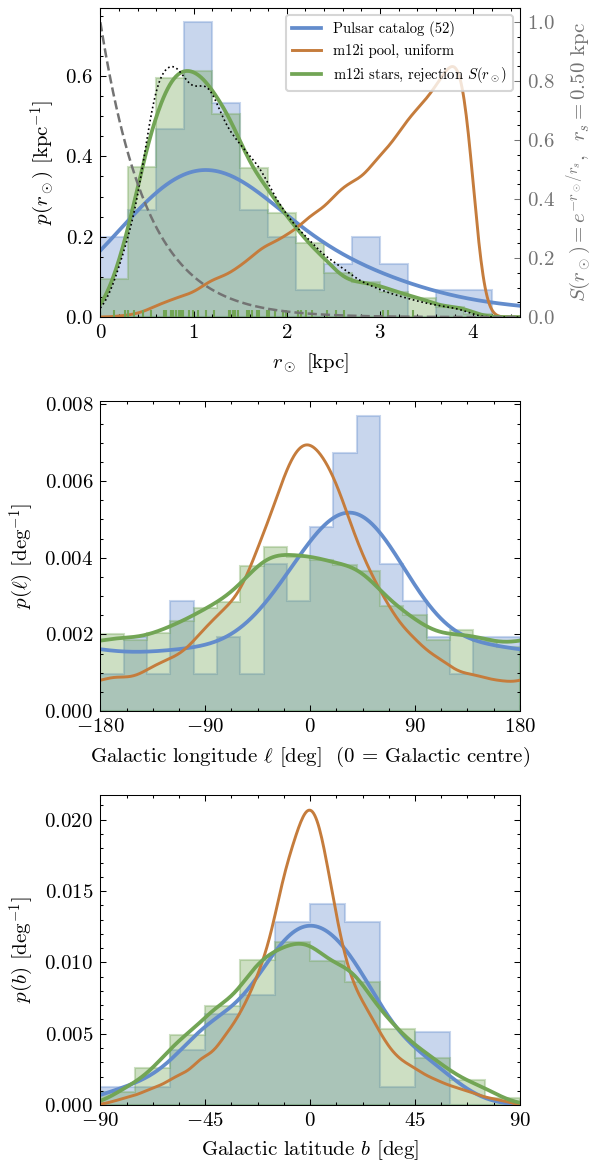

In [38]:
C_SEL = PAPER_PALETTE[3]   # green: the rejection-sampled, catalog-like pool

# # analytic target on the r panel: uniform volume x S(r), i.e. Gamma(3, r_s)
# p_target = gamma(3, scale=r_s).pdf(rg)


bins_r = np.linspace(0, 4.5, 16)     # 15 bins of 0.3 kpc
bins_l = np.linspace(-180, 180, 19)  # 18 bins of 20 deg
bins_b = np.linspace(-90, 90, 13)    # 12 bins of 15 deg

panels = [  # (axis label, catalog, uniform pool, rejection sample, grid, bins, period)
    (r"$r_\odot$ [kpc]", r_cat, r_sim, r_sel, rg, bins_r, None),
    (r"Galactic longitude $\ell$ [deg]  (0 = Galactic centre)", l_cat, l_sim, l_sel, lg, bins_l, 360.0),
    (r"Galactic latitude $b$ [deg]", b_cat, b_sim, b_sel, bg, bins_b, None),
]


kde = lambda s, grid, period: (gaussian_kde(s)(grid) if period is None
                               else periodic_kde(s, grid, period))

fig, axes = plt.subplots(3, 1, figsize=(4.2, 8.0))
for ax, (label, cat, uni, sel, grid, bn, period) in zip(axes, panels):
    ax.hist(cat, bins=bn, density=True, histtype="stepfilled",
            color=C_CAT, alpha=0.35, edgecolor=C_CAT, lw=1.2)
    ax.hist(sel, bins=bn, density=True, histtype="stepfilled",
            color=C_SEL, alpha=0.35, edgecolor=C_SEL, lw=1.2)
    ax.plot(grid, kde(cat, grid, period), color=C_CAT, lw=1.8, label="Pulsar catalog (52)")
    ax.plot(grid, kde(uni, grid, period), color=C_SIM, lw=1.4, label="m12i pool, uniform")
    ax.plot(grid, kde(sel, grid, period), color=C_SEL, lw=1.8,
            label=r"m12i stars, rejection $S(r_\odot)$")
    ax.set_xlim(grid[0], grid[-1])
    ax.set_xlabel(label)

# the selection function itself, on its own 0-1 axis: green = orange x S, renormalised
axS = axes[0].twinx()
axS.plot(rg, S(rg), color=C_REF, ls="--", lw=1.2)
axS.set_ylim(0, 1.05)
axS.set_ylabel(r"$S(r_\odot) = e^{-r_\odot/r_s}$,  $r_s = %.2f$ kpc" % r_s, color=C_REF)
axS.tick_params(axis="y", colors=C_REF)
q = p_sim * S(rg); axes[0].plot(rg, q / np.trapezoid(q, rg), color="k", ls=":", lw=0.8)


axes[0].plot(r_sel[idx_50], np.zeros(50), "|", color=C_SEL, ms=7, mew=1.0)   # one n=50 draw
axes[0].set_ylabel(r"$p(r_\odot)$ [kpc$^{-1}$]")
axes[0].legend(frameon=True, fontsize=7)
axes[1].set_xticks([-180, -90, 0, 90, 180]); axes[1].set_ylabel(r"$p(\ell)$ [deg$^{-1}$]")
axes[2].set_xticks([-90, -45, 0, 45, 90]);   axes[2].set_ylabel(r"$p(b)$ [deg$^{-1}$]")
fig.tight_layout()
fig.savefig("../../../accelerations-paper/figures/sampling_comparison_rejection.pdf")


In [39]:
rows = [("median r_sun [kpc]",  lambda r, l, b, z: np.median(r)),
        ("frac |l| < 90 deg",   lambda r, l, b, z: np.mean(np.abs(l) < 90)),
        ("median |b| [deg]",    lambda r, l, b, z: np.median(np.abs(b))),
        ("median |z| [kpc]",    lambda r, l, b, z: np.median(np.abs(z))),
        ("84th pct |z| [kpc]",  lambda r, l, b, z: np.percentile(np.abs(z), 84))]
samples = {"catalog": (r_cat, l_cat, b_cat, z_cat),
           "uniform": (r_sim, l_sim, b_sim, z_sim),
           "rejection": (r_sel, l_sel, b_sel, z_sel)}
print(f"{'':22s}" + "".join(f"{k:>11s}" for k in samples))
for name, f in rows:
    print(f"{name:22s}" + "".join(f"{f(*v):11.2f}" for v in samples.values()))


                          catalog    uniform  rejection
median r_sun [kpc]           1.23       3.11       1.20
frac |l| < 90 deg            0.71       0.79       0.63
median |b| [deg]            19.89      14.14      23.82
median |z| [kpc]             0.42       0.66       0.43
84th pct |z| [kpc]           0.69       1.62       0.95


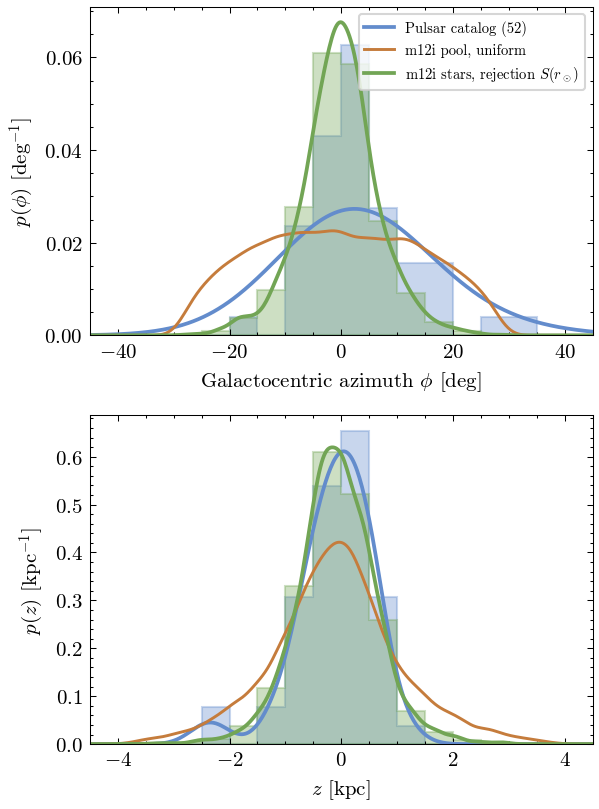

In [40]:
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(4.2, 5.6))
for ax, cat, uni, sel, grid, bn, label in [
        (ax0, phi_cat, phi_sim, phi_sel, phig, np.linspace(-45, 45, 19), r"Galactocentric azimuth $\phi$ [deg]"),
        (ax1, z_cat, z_sim, z_sel, zg, np.linspace(-4.5, 4.5, 19), r"$z$ [kpc]")]:
    ax.hist(cat, bins=bn, density=True, histtype="stepfilled", color=C_CAT, alpha=0.35, edgecolor=C_CAT, lw=1.2)
    ax.hist(sel, bins=bn, density=True, histtype="stepfilled", color=C_SEL, alpha=0.35, edgecolor=C_SEL, lw=1.2)
    ax.plot(grid, gaussian_kde(cat)(grid), color=C_CAT, lw=1.8, label="Pulsar catalog (52)")
    ax.plot(grid, gaussian_kde(uni)(grid), color=C_SIM, lw=1.4, label="m12i pool, uniform")
    ax.plot(grid, gaussian_kde(sel)(grid), color=C_SEL, lw=1.8, label=r"m12i stars, rejection $S(r_\odot)$")
    ax.set_xlim(grid[0], grid[-1]); ax.set_xlabel(label)
ax0.set_ylabel(r"$p(\phi)$ [deg$^{-1}$]"); ax0.legend(frameon=True, fontsize=7)
ax1.set_ylabel(r"$p(z)$ [kpc$^{-1}$]")
fig.tight_layout()


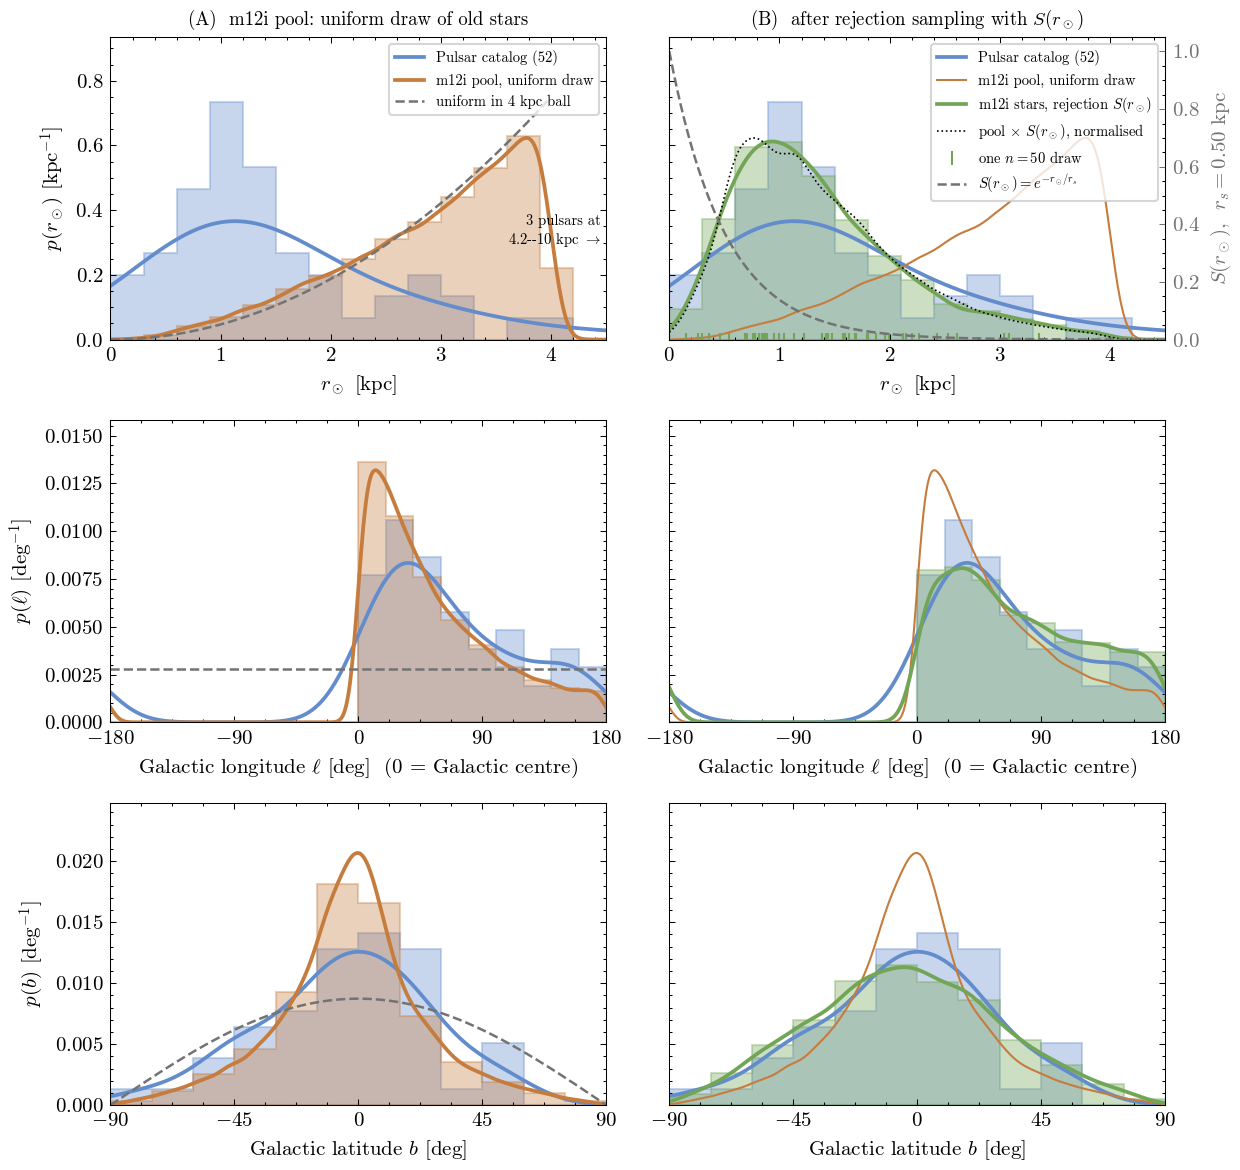

In [47]:
# Combined figure: the two (r_sun, l, b) comparisons above side by side.
#   column A = catalog vs the uniform draw of the m12i pool (+ uniform-in-ball reference)
#   column B = catalog vs the rejection-sampled m12i stars (+ S(r), analytic target, one n=50 draw)
# Every panel has the same size as in the single-column figures (4.2 x 8.0 / 3 each), the
# same fonts, the same bins (15 x 0.3 kpc, 18 x 20 deg, 12 x 15 deg) and shared y-axes per row.
C_SEL = PAPER_PALETTE[3]
bins_r = np.linspace(0, 4.5, 16)     # 15 bins of 0.3 kpc
bins_l = np.linspace(-180, 180, 19)  # 18 bins of 20 deg
bins_b = np.linspace(-90, 90, 13)    # 12 bins of 15 deg
HIST = dict(density=True, histtype="stepfilled", alpha=0.35, lw=1.2)

kde = lambda s, grid, period=None: (gaussian_kde(s)(grid) if period is None
                                    else periodic_kde(s, grid, period))

rows = [  # (xlabel, ylabel, catalog, pool, rejection, isotropic reference, grid, bins, period, xticks, headroom)
    (r"$r_\odot$ [kpc]", r"$p(r_\odot)$ [kpc$^{-1}$]",
     r_cat, r_sim, r_sel, p_uni, rg, bins_r, None, None, 1.5),
    (r"Galactic longitude $\ell$ [deg]  (0 = Galactic centre)", r"$p(\ell)$ [deg$^{-1}$]",
     np.abs(l_cat), np.abs(l_sim), np.abs(l_sel), p_l_uni, lg, bins_l, 360.0, [-180, -90, 0, 90, 180], 1.2),
    (r"Galactic latitude $b$ [deg]", r"$p(b)$ [deg$^{-1}$]",
     b_cat, b_sim, b_sel, p_b_uni, bg, bins_b, None, [-90, -45, 0, 45, 90], 1.2),
]

fig, axes = plt.subplots(3, 2, figsize=(8.4, 8.0), sharey="row")
for (xlabel, ylabel, cat, uni, sel, ref, grid, bn, period, xticks, headroom), (axA, axB) in zip(rows, axes):
    p_c, p_u, p_s = kde(cat, grid, period), kde(uni, grid, period), kde(sel, grid, period)

    # (A) catalog vs uniform pool, with the uniform-in-ball / isotropic reference
    axA.hist(cat, bins=bn, color=C_CAT, edgecolor=C_CAT, **HIST)
    axA.hist(uni, bins=bn, color=C_SIM, edgecolor=C_SIM, **HIST)
    axA.plot(grid, p_c, color=C_CAT, lw=1.8, label="Pulsar catalog (52)")
    axA.plot(grid, p_u, color=C_SIM, lw=1.8, label="m12i pool, uniform draw")
    axA.plot(grid, ref, color=C_REF, ls="--", lw=1.2, label="uniform in 4 kpc ball")

    # (B) catalog vs rejection-sampled stars; the pool KDE stays as a thin reference
    axB.hist(cat, bins=bn, color=C_CAT, edgecolor=C_CAT, **HIST)
    axB.hist(sel, bins=bn, color=C_SEL, edgecolor=C_SEL, **HIST)
    axB.plot(grid, p_c, color=C_CAT, lw=1.8, label="Pulsar catalog (52)")
    axB.plot(grid, p_u, color=C_SIM, lw=1.0, label="m12i pool, uniform draw")
    axB.plot(grid, p_s, color=C_SEL, lw=1.8, label=r"m12i stars, rejection $S(r_\odot)$")

    for ax in (axA, axB):
        ax.set_xlim(grid[0], grid[-1])
        ax.set_xlabel(xlabel)
        if xticks is not None:
            ax.set_xticks(xticks)
    axA.set_ylabel(ylabel)
    axA.set_ylim(0, headroom * max(p_c.max(), p_u.max(), p_s.max()))   # room for the legends

# top-left: the far catalog pulsars (bottom-right corner, where nothing is drawn beyond 4 kpc)
axes[0, 0].annotate("3 pulsars at\n4.2--10 kpc $\\rightarrow$", xy=(4.45, 0.28),
                    ha="right", va="bottom", fontsize=7, color="k")
# top-right: S(r) on its own 0-1 axis, the analytic target, and one experiment-sized draw
axS = axes[0, 1].twinx()
axS.plot(rg, S(rg), color=C_REF, ls="--", lw=1.2, label=r"$S(r_\odot) = e^{-r_\odot/r_s}$")
axS.set_ylim(0, 1.05)
axS.set_ylabel(r"$S(r_\odot)$,  $r_s = %.2f$ kpc" % r_s, color=C_REF)
axS.tick_params(axis="y", colors=C_REF)
q = kde(r_sim, rg) * S(rg)
axes[0, 1].plot(rg, q / np.trapezoid(q, rg), color="k", ls=":", lw=0.8,
                label=r"pool $\times$ $S(r_\odot)$, normalised")
axes[0, 1].plot(r_sel[idx_50], np.zeros(50), "|", color=C_SEL, ms=7, mew=1.0,
                label=r"one $n = 50$ draw")

axes[0, 0].set_title("(A)  m12i pool: uniform draw of old stars", fontsize=9)
axes[0, 1].set_title(r"(B)  after rejection sampling with $S(r_\odot)$", fontsize=9)
axes[0, 0].legend(frameon=True, fontsize=7, loc="upper right")
hB, lB = axes[0, 1].get_legend_handles_labels()
hS, lS = axS.get_legend_handles_labels()
axes[0, 1].legend(hB + hS, lB + lS, frameon=True, fontsize=7, loc="upper right")
fig.tight_layout()
fig.savefig("../../../accelerations-paper/figures/sampling_comparison_6panel.pdf")